# A Multigroup Adjoint Response

In this example we will explore leveraging an adjoint formulation of the linear boltzmann equations for computing response functions in a desired region of interest (RoI). This problem builds upon a corresponding problem in [A Multigroup 1D Detector](../detector/detector_1d.ipynb). Additional information on the adjoint formalism is in the theory manual [here](../../../theory/adjoint.rst).

This is a complete simulation transport example. Each aspect of this example can be broken as follows:
- [Prerequisites](#prerequisites)
- [Mesh](#mesh)
- [Geometry](#geometry)
    - [Material IDs](#material-ids)
    - [Cross Sections](#cross-sections)
- [Solver](#Solver)
    - [Physics Options](#physics-options)
    - [Angular Quadrature](#angular-quadrature)
    - [Group Structure](#group-structure)
    - [Adjoint Source Definitionn](#adjoint-source-definition)
    - [Discrete Ordinates Problem](#discrete-ordinates-problem)
    - [Execute](#execute)
- [Post Processing](#post-processing)
    - [Write Flux Moments](#write-flux-moments)
    - [Detector Response](#detector-response)
    - [Linear Field Function](#linear-field-function)
    - [Compute Leakage](#compute-leakage)
    - [Compute Balance](#compute-balance)

---
## **Prerequisites**

Before running this example, make sure that the **Python module of OpenSn** was installed.

### Converting and Running this Notebook from the Terminal
To run this notebook from the terminal, simply type:

`jupyter nbconvert --to python --execute detector_1d.ipynb`.

To run this notebook in parallel (for example, using 4 processes), simply type:

`mpiexec -n 4 jupyter nbconvert --to python --execute detector_1d.ipynb`.

In [1]:
from mpi4py import MPI
size = MPI.COMM_WORLD.size
rank = MPI.COMM_WORLD.rank
barrier = MPI.COMM_WORLD.barrier

if rank == 0:
    print(f"Running the LBS 1D Detector example with {size} MPI processors.")

Running the LBS 1D Detector example with 1 MPI processors.


### Import Requirements

Import required classes and functions from the Python interface of OpenSn. Make sure that the path
to PyOpenSn is appended to Python's PATH.

In [2]:
import os
import sys
import math
import numpy as np

# assuming that the execute dir is the notebook dir
# this line is not necessary when PyOpenSn is installed using pip
sys.path.append("../../..")

from pyopensn.mesh import OrthogonalMeshGenerator
from pyopensn.xs import MultiGroupXS
from pyopensn.source import PointSource, VolumetricSource
from pyopensn.aquad import GLProductQuadrature1DSlab
from pyopensn.solver import DiscreteOrdinatesProblem, SteadyStateSourceSolver
from pyopensn.response import ResponseEvaluator
from pyopensn.math import Vector3, VectorSpatialFunction
from pyopensn.fieldfunc import FieldFunctionInterpolationVolume, \
                               FieldFunctionInterpolationLine, \
                               FieldFunctionGridBased
from pyopensn.logvol import RPPLogicalVolume
from pyopensn.context import UseColor, Finalize

OpenSn version 0.0.1
2025-09-13 10:54:03 Running OpenSn with 1 processes.



---
## **Mesh**
![Detector](images/detector.png)


Here, we will use the in-house orthogonal mesh generator for a simple Cartesian grid.

We first create a list of nodes for spatial dimension in the Z direction. For material interfaces in our problem we will create a function `getNodes()`. Given material boundaries and the number of cells within each boundary the function returns a python list of node values. 

In [3]:
def getNodes(n, dn, ref=1):
    '''
    n: list of material interfaces
    dn: number of cells for each region
    ref(default=1): refine the number of cells by an integer multiple
    '''
    dn = [i * ref for i in dn]
    nodes = []
    for i in range(len(n[:-1])):
        edges = np.linspace(n[i],n[i+1],dn[i]+1)
        if len(nodes) == 0:
            nodes = edges
        else:
            nodes = [*nodes, *edges[1:]]
    return list(nodes)

# Source Interfaces
src = [2.7, 2.8, 3.2, 3.3]
d_src = [2, 4, 2]

# Detector Interfaces
det = [13.0, 16.73, 16.8, 19.2, 19.27, 23.0]
d_det = [6, 2, 4, 2, 6]

z = [0.0, *src, *det, 25.0]
dz = [4, *d_src, 10, *d_det, 4]
nodesz = getNodes(z, dz, ref=10)

### Orthogonal Mesh Generation
We use the `OrthogonalMeshGenerator` and pass the list of nodes per dimension. Here, we pass our lsit of nodes for the z direction creating a 1D geometry of length 25 cm. 

In [4]:
meshgen = OrthogonalMeshGenerator(node_sets=[nodesz])
grid = meshgen.Execute()

[0]  Done checking cell-center-to-face orientations
[0]  00:00:00.1 Establishing cell connectivity.
[0]  00:00:00.1 Vertex cell subscriptions complete.
[0]  00:00:00.1 Surpassing cell 46 of 460 (10%)
[0]  00:00:00.1 Surpassing cell 92 of 460 (20%)
[0]  00:00:00.1 Surpassing cell 139 of 460 (30%)
[0]  00:00:00.1 Surpassing cell 184 of 460 (40%)
[0]  00:00:00.1 Surpassing cell 230 of 460 (50%)
[0]  00:00:00.1 Surpassing cell 277 of 460 (60%)
[0]  00:00:00.1 Surpassing cell 323 of 460 (70%)
[0]  00:00:00.1 Surpassing cell 368 of 460 (80%)
[0]  00:00:00.1 Surpassing cell 414 of 460 (90%)
[0]  00:00:00.1 Surpassing cell 460 of 460 (100%)
[0]  00:00:00.1 Establishing cell boundary connectivity.
[0]  00:00:00.1 Done establishing cell connectivity.
[0]  Number of cells per partition (max,min,avg) = 460,460,460
[0]  
[0]  Mesh statistics:
[0]    Global cell count             : 460
[0]    Local cell count (avg,max,min): 460,460,460
[0]    Ghost-to-local ratio (avg)    : 0
[0]  


---
## **Geometry**

### Material IDs
When using the in-house `OrthogonalMeshGenerator`, no material IDs are assigned. The user needs to assign material IDs to all cells. We will begin by assigning the background material ID with a value of 0.

In [5]:
bkgrnd = RPPLogicalVolume(
    infx=True, 
    infy=True, 
    infz=True
)
grid.SetBlockIDFromLogicalVolume(bkgrnd, 0, True)

Next we will assign material IDs for the detector and source. When assigning material IDs via logical volumes the IDs for each cell is overriden by the most recent assignment. That is to say, assigning a material ID of 1 to any region in our domain will override the previously set ID to those cells. 

In [6]:
# Detector Volume
det_hdpe = RPPLogicalVolume(
            infx=True,
            infy=True,
            zmin=det[0], zmax=det[-1],
)
grid.SetBlockIDFromLogicalVolume(det_hdpe, 1, True)

det_sleeve = RPPLogicalVolume(
            infx=True,
            infy=True,
            zmin=det[1], zmax=det[-2],
)
grid.SetBlockIDFromLogicalVolume(det_sleeve, 2, True)

det_he3 = RPPLogicalVolume(
            infx=True,
            infy=True,
            zmin=det[2], zmax=det[-3],
)
grid.SetBlockIDFromLogicalVolume(det_he3, 3, True)

In [7]:
# Src Volume
src_casing = RPPLogicalVolume(
            infx=True,
            infy=True,
            zmin=src[0], zmax=src[-1],
)
grid.SetBlockIDFromLogicalVolume(src_casing, 2, True)

src_cf = RPPLogicalVolume(
            infx=True,
            infy=True,
            zmin=src[1], zmax=src[-2],
)
grid.SetBlockIDFromLogicalVolume(src_cf, 4, True)


### Cross Sections
In this problem we are running a multigroup problem for the absoprtion reaction rate in a He-3 detector. This begins with importing our multigroup cross sections. In this case we will be using the WIMS69 group structure for 5 materials:
- Air
- HDPE
- SS-316
- He-3
- Cf-252

In [8]:
xs_dir = "WIMS69"
xs_air = MultiGroupXS()
xs_air.LoadFromOpenSn(xs_dir+"/Air.cxs")

xs_hdpe = MultiGroupXS()
xs_hdpe.LoadFromOpenSn(xs_dir+"/HDPE.cxs")

xs_steel = MultiGroupXS()
xs_steel.LoadFromOpenSn(xs_dir+"/SS_316.cxs")

xs_he3 = MultiGroupXS()
xs_he3.LoadFromOpenSn(xs_dir+"/He3.cxs")

xs_cf = MultiGroupXS()
xs_cf.LoadFromOpenSn(xs_dir+"/Cf252.cxs")

xsecs = [{"block_ids": [0], "xs": xs_air},
         {"block_ids": [1], "xs": xs_hdpe},
         {"block_ids": [2], "xs": xs_steel},
         {"block_ids": [3], "xs": xs_he3},
         {"block_ids": [4], "xs": xs_cf}]

[0]  Reading OpenSn cross-section file "WIMS69/Air.cxs"
[0]  Reading OpenSn cross-section file "WIMS69/HDPE.cxs"
[0]  Reading OpenSn cross-section file "WIMS69/SS_316.cxs"
[0]  Reading OpenSn cross-section file "WIMS69/He3.cxs"
[0]  Reading OpenSn cross-section file "WIMS69/Cf252.cxs"


---
## **Solver**

### Physics Options 

To run an adjoint problem we pass `adjoint=True`. 

In [9]:
phys_opts = {
    "boundary_conditions": [
        {"name": "xmin", "type": "reflecting"},
        {"name": "xmax", "type": "reflecting"},
        {"name": "ymin", "type": "reflecting"},
        {"name": "ymax", "type": "reflecting"},
        {"name": "zmin", "type": "vacuum"},
        {"name": "zmax", "type": "vacuum"}
    ],
    "save_angular_flux": True,
    "adjoint": True,
}

### Angular Quadrature
Since we are solving a 1D problem we will create Gauss-Legendre Product Quadrature for a 1D slab which requires the total angles and the scattering order. In this case we will use 512 angles creating a 1D angular quadrature in $\mu$ with a scattering order of 1.

In [10]:
pquad = GLProductQuadrature1DSlab(n_polar=512, 
                                  scattering_order=1)

[0]  Using 1D Slab Gauss–Legendre product quadrature with 512 angles and weight sum of 1.00


### Group Structure

In [11]:
num_groups = 69
groups = [1.00000E-11, 5.00000E-09, 1.00000E-08, 1.50000E-08, 2.00000E-08, 
          2.50000E-08, 3.00000E-08, 3.50000E-08, 4.20000E-08, 5.00000E-08, 
          5.80000E-08, 6.70000E-08, 8.00000E-08, 1.00000E-07, 1.40000E-07, 
          1.80000E-07, 2.20000E-07, 2.50000E-07, 2.80000E-07, 3.00000E-07, 
          3.20000E-07, 3.50000E-07, 4.00000E-07, 5.00000E-07, 6.25000E-07, 
          7.80000E-07, 8.50000E-07, 9.10000E-07, 9.50000E-07, 9.72000E-07, 
          9.96000E-07, 1.02000E-06, 1.04500E-06, 1.07100E-06, 1.09700E-06, 
          1.12300E-06, 1.15000E-06, 1.30000E-06, 1.50000E-06, 2.10000E-06, 
          2.60000E-06, 3.30000E-06, 4.00000E-06, 9.87700E-06, 1.59680E-05, 
          2.77000E-05, 4.80520E-05, 7.55014E-05, 1.48729E-04, 3.67263E-04, 
          9.06899E-04, 1.42510E-03, 2.23945E-03, 3.51910E-03, 5.53000E-03, 
          9.11800E-03, 1.50300E-02, 2.47800E-02, 4.08500E-02, 6.73400E-02, 
          1.11000E-01, 1.83000E-01, 3.02500E-01, 5.00000E-01, 8.21000E-01, 
          1.35300E+00, 2.23100E+00, 3.67900E+00, 6.06550E+00, 1.00000E+01]
grpsets = [
    {
        "groups_from_to": (0, num_groups-1),
        "angular_quadrature": pquad,
        "inner_linear_method": "petsc_gmres",
        "l_abs_tol": 1.0e-6,
        "l_max_its": 300,
        "gmres_restart_interval": 100,
    },
]

### Adjoint Source Definition

For solving the 1D transport problem via the adjoint operator we first define our adjoint source $q^{\dagger}$ to be the detector volume and apply a source strength equivalent to the abosrption cross section of our detector $\sigma^{He3,g}_a$. (By default, adjoint sources are isotoropically distributed in angle across the souce domain)

To do this we create a `ResponseFunction`. A response function takes the place of defining the group strength. This can be used to specifiy responses to specific energy bins, or this case, capture our detector response.

In [12]:
def ResponseFunction(xyz, mat_id):
    response = xs_he3.sigma_a
    return response
response_func = VectorSpatialFunction(ResponseFunction)

adj_src = VolumetricSource(logical_volume=det_he3, func=response_func)
phys_opts["volumetric_sources"] = [adj_src]

### Discrete Ordinates Problem
For the problem block, we provide
+ mesh : The mesh
+ num_groups : The number of energy groups
+ groupsets : The groupsets block
+ scattering_order : The scattering order
+ xs_map : Cross section map
+ options : Physics solver options

In [13]:
phys = DiscreteOrdinatesProblem(
    mesh=grid,
    num_groups=num_groups,
    groupsets=grpsets,
    scattering_order=1,
    xs_map=xsecs,
    options=phys_opts
)

### Execute
We then create the physics solver, initialize it, and execute it.

In [14]:
ss_solver = SteadyStateSourceSolver(problem=phys)
ss_solver.Initialize()
ss_solver.Execute()

[0]  
[0]  Initializing LBS SteadyStateSourceSolver with name: LBSDiscreteOrdinatesProblem
[0]  
[0]  Scattering order    : 1
[0]  Number of Groups    : 69
[0]  Number of Group sets: 1
[0]  
[0]  ***** Groupset 0 *****
[0]  Groups:
[0]      0     1     2     3     4     5     6     7     8     9    10    11 
[0]     12    13    14    15    16    17    18    19    20    21    22    23 
[0]     24    25    26    27    28    29    30    31    32    33    34    35 
[0]     36    37    38    39    40    41    42    43    44    45    46    47 
[0]     48    49    50    51    52    53    54    55    56    57    58    59 
[0]     60    61    62    63    64    65    66    67    68 
[0]  
[0]  Initializing spatial discretization.
[0]  Computing unit integrals.
[0]  Ghost cell unit cell-matrix ratio: 0%
[0]  Cell matrices computed.
[0]  *** WARNING ***  Computing the flux with fewer scattering moments than are present in the cross-section data for block 0
[0]  *** WARNING ***  Computing the flux 

## Post Processing

### Write Flux Moments
When evaluating response functions via the adjoint formalism its efficiency derives from having access to the adjoint solution $\phi^{\dagger,g}$. For this, we export the adjoint flux moments to a .h5 file using `WriteFluxMoments`. The adjoint data is then saved to a location of our choosing.  

In [15]:
data_dir = os.getcwd()+"/Data"
os.makedirs(data_dir, exist_ok=True)

phys.WriteFluxMoments(data_dir+"/adjphi_p")

[0]  Writing flux moments to /home/jason/Documents/Work/OpenSn/opensn-jay/doc/source/tutorials/lbs/src_driven/adjdetector/Data/adjphi_p


### Detector Response

An adjoint formulation has no meaning without a forward response to provide a detector response. For the volumetric source we first define the forward source sprectrum. In this case we will assign a uniform spectrum in energy distributed along the source logical volume. Using `VolumetricSource` we assign this group-wise source definition to material ID 4. 

In [16]:
group_width = np.flip(np.diff(groups))
dE = groups[-1] - groups[0]
dL = src[-2] - src[1]
Q = (group_width / dE / dL).tolist()

fwd_src = {'material': [{'block_id': 4, 'strength': Q}]}

With the adjoint data in hand, we now create a `ResponseEvaluator`. 

We now supply two additional options to the `evaluator`, the `buffers` (adjoint data) and the `sources`. For computing the detector response we make use of `EvaluateResponse` which given a buffer name will compute an inner product of the adjoint flux $\phi^{\dagger,}$ against the forward source $q$ using the [duality principle](../../../theory/adjoint.rst) such that:

$$
\text{QoI} = \sum^G_g \, \int_\mathcal{D} d^3r \, \int_{(4\pi)}   d\Omega  \, q^g(\vec{r},\vec\Omega) \psi^{\dagger,g}(\vec{r},\vec\Omega) = \sum^G_g \, \int_\mathcal{D}  d^3r  \, q^g(\vec{r}) \phi^{\dagger,g}(\vec{r})
$$

In [17]:

evaluator = ResponseEvaluator(problem = phys)
evaluator.SetOptions(
    buffers = [{
        'name': 'detector', 
        'file_prefixes': {'flux_moments': data_dir+'/adjphi_p'}
    }],
    sources = fwd_src
)
adj_resp = evaluator.EvaluateResponse("detector")
print(adj_resp)

0.12060971506714085[0]  Reading flux moments from /home/jason/Documents/Work/OpenSn/opensn-jay/doc/source/tutorials/lbs/src_driven/adjdetector/Data/adjphi_p



With our field function defined, we can also export the multi-group adjoint flux moments, $\phi^{\dagger,g}$, to a .vtu file using ``ExportMultipleToPVTU``.

In [18]:
fflist = phys.GetScalarFieldFunctionList(only_scalar_flux=False)
fields = []
for g in range(num_groups):
    fields.append(fflist[g][0])

FFGrid = FieldFunctionGridBased
FFGrid.ExportMultipleToPVTU(fields, "AdjFlux/adjdetector_p")

[0]  Exporting field functions to PVTU with file base "AdjFlux/adjdetector_p"
[0]  Done exporting field functions to PVTU.


### Linear Field Function
To plot the scalar flux along a line segment of the problem we use ``FieldFunctionInterpolationLine()``

[0]  Exported CSV file for field func "phi_g000_m00" to "AdjFlux/adjdetector_phi_g000_m00.csv"
[0]  Exported CSV file for field func "phi_g001_m00" to "AdjFlux/adjdetector_phi_g001_m00.csv"
[0]  Exported CSV file for field func "phi_g002_m00" to "AdjFlux/adjdetector_phi_g002_m00.csv"
[0]  Exported CSV file for field func "phi_g003_m00" to "AdjFlux/adjdetector_phi_g003_m00.csv"
[0]  Exported CSV file for field func "phi_g004_m00" to "AdjFlux/adjdetector_phi_g004_m00.csv"
[0]  Exported CSV file for field func "phi_g005_m00" to "AdjFlux/adjdetector_phi_g005_m00.csv"
[0]  Exported CSV file for field func "phi_g006_m00" to "AdjFlux/adjdetector_phi_g006_m00.csv"
[0]  Exported CSV file for field func "phi_g007_m00" to "AdjFlux/adjdetector_phi_g007_m00.csv"
[0]  Exported CSV file for field func "phi_g008_m00" to "AdjFlux/adjdetector_phi_g008_m00.csv"
[0]  Exported CSV file for field func "phi_g009_m00" to "AdjFlux/adjdetector_phi_g009_m00.csv"
[0]  Exported CSV file for field func "phi_g010_m0

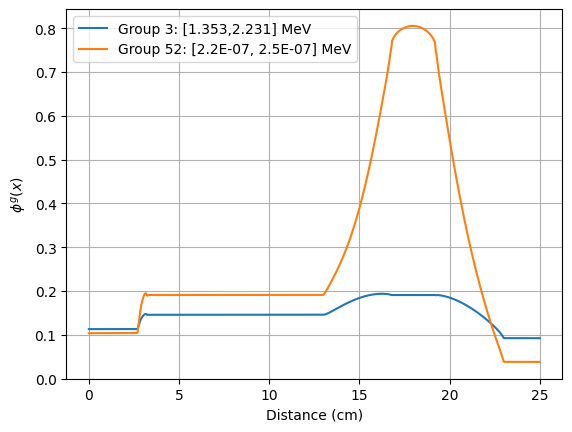

In [19]:
import csv
from os import walk
import matplotlib.pyplot as plt

for g in range(num_groups):
    # Linear Field Function
    ffline = FieldFunctionInterpolationLine()
    ffline.SetInitialPoint(Vector3(0.0, 0.0, z[0]))
    ffline.SetFinalPoint(Vector3(0.0, 0.0, z[-1]))
    ffline.SetNumberOfPoints(1000)
    ffline.AddFieldFunction(fflist[g][0])
    ffline.Initialize()
    ffline.Execute()
    ffline.ExportToCSV("AdjFlux/adjdetector")

# Convert each CSV to a python dictionary
def CSVToDict(filename):
    data = {}
    with open(filename, newline="") as csvfile:
        reader = csv.DictReader(csvfile)
        for row in reader:
            for key, value in row.items():
                data.setdefault(key, []).append(float(value))
    return data

# Collect each groupwise flux distribution into a dictionary
# Flux -> g001 -> {x,y,z,phi_g001_m00}
#      -> g002 -> {x,y,z,phi_g002_m00}
#      -> .... ->         ...
#      -> g068 -> {x,y,z,phi_g068_m00}        
Flux = {}
for (dirpath, dirnames, filenames) in walk('AdjFlux/'):
   for filename in filenames:
        if filename.split(".")[1] == "csv":
            grp = filename.split('.')[0].split('_')[2]
            key = "_".join(filename.split('.')[0].split('_')[1:])
            fwd_dict = CSVToDict("AdjFlux/"+filename)
            Flux[grp] = CSVToDict("AdjFlux/"+filename)

# Plot of the flux distribution
z = Flux['g003']['z']
flux_g3 = Flux['g003']['phi_g003_m00']
flux_g52 = Flux['g052']['phi_g052_m00']

plt.figure()
plt.plot(z, flux_g3, label="Group 3: [1.353,2.231] MeV")
plt.plot(z, flux_g52, label="Group 52: [2.2E-07, 2.5E-07] MeV")
plt.xlabel("Distance (cm)")
plt.ylabel(r"$\phi^g(x)$")
plt.legend()
plt.grid()
plt.show()


### Compute Leakage
We can simultanously compute the groupwise leakage rate at the boundaries, $\vec{j}^{\dagger,g}_{\text{+}}|_{\Gamma}$,  of the problem domain.

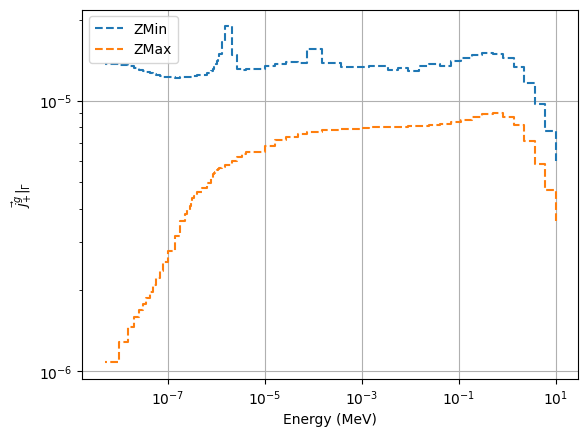

Total Leakage ZMin:  0.0009130934513907682 
Total Leakage ZMax:  0.00037990652242912666
Total Leakage :  0.001292999973819895


In [20]:
leakage = phys.ComputeLeakage(["zmin", "zmax"]) 
lkg_zmin = leakage['zmin']
lkg_zmax = leakage['zmax']
erg = np.flip(groups[1:])

plt.figure()
plt.loglog(erg, lkg_zmin, "--", drawstyle='steps', label="ZMin")
plt.loglog(erg, lkg_zmax, "--",  drawstyle='steps', label="ZMax")
plt.xlabel("Energy (MeV)")
plt.ylabel(r"$\vec{j}^{g}_{\text{+}}|_{\Gamma}$")
plt.legend()
plt.grid()
plt.show()

print("Total Leakage ZMin: ", np.sum(lkg_zmin),"\nTotal Leakage ZMax: ",np.sum(lkg_zmax))
print("Total Leakage : ", np.sum(lkg_zmin)+np.sum(lkg_zmax))

### Compute Balance

In [21]:
balance = phys.ComputeBalance()

[0]  Balance table:
[0]   Absorption rate             = 2.989131e+01
[0]   Production rate             = 3.342863e+01
[0]   In-flow rate                = 0.000000e+00
[0]   Out-flow rate               = 6.313274e+00
[0]   Gain (In-flow + Production) = 3.342863e+01
[0]   Balance (Gain - Loss)       = -2.775949e+00
[0]   Balance/Gain, in %          = -8.304106e+00


## Finalize (for Jupyter Notebook only)

In Python script mode, PyOpenSn automatically handles environment termination. However, this
automatic finalization does not occur when running in a Jupyter notebook, so explicit finalization
of the environment at the end of the notebook is required. Do not call the finalization in Python
script mode, or in console mode.

Note that PyOpenSn's finalization must be called before MPI's finalization.


In [22]:
from IPython import get_ipython

def finalize_env():
    Finalize()
    MPI.Finalize()

ipython_instance = get_ipython()
if ipython_instance is not None:
    ipython_instance.events.register("post_execute", finalize_env)

os.system("rm -rf Data AdjFlux Results")


0


Elapsed execution time: 00:00:45.2
2025-09-13 10:54:48 OpenSn finished execution.
